In [1]:
import gensn
import gensn.distributions as G
import torch
import torch.distributions as D
import numpy as np
from numpy.random import default_rng
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam
from task_transfer.routines import mc_marginal_log_likelihood

seed = 1123
torch.manual_seed(seed)
rng = default_rng(seed)

# Define number of neurons and dimensionality of images

In [2]:
n_neurons = 2
n_image_dims = 3

# Define the ground truth brain generative model for each task 1 and task 2

In [3]:
t1_prior_mean = torch.tensor([2., -1.])
t1_prior_cov = torch.rand((n_neurons, n_neurons))
t1_prior_cov = t1_prior_cov @ t1_prior_cov.T + torch.finfo(t1_prior_cov.dtype).eps * torch.eye(
    n_neurons
)
t1_prior = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=t1_prior_mean, covariance_matrix=t1_prior_cov
)

In [4]:
t2_prior_mean = torch.tensor([-2., 2.])
t2_prior_cov = torch.rand((n_neurons, n_neurons))
t2_prior_cov = t2_prior_cov @ t2_prior_cov.T + torch.finfo(
    t2_prior_cov.dtype
).eps * torch.eye(n_neurons)
t2_prior_cov = -t2_prior_cov * -torch.eye(n_neurons)
t2_prior = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=t2_prior_mean, covariance_matrix=t2_prior_cov
)

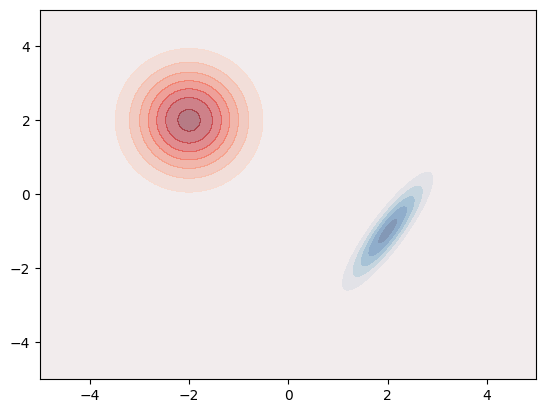

In [5]:
x, y = np.mgrid[-5:5:.01, -5:5:.01]
pos = np.dstack((x, y))

t1_pdf = t1_prior(torch.tensor(pos)).exp()
t2_pdf = t2_prior(torch.tensor(pos)).exp()

fig, ax = plt.subplots(dpi=100)
ax.contourf(x, y, t1_pdf, cmap="Blues")
ax.contourf(x, y, t2_pdf, cmap="Reds", alpha=0.5)

In [6]:
likelihood_fn = torch.nn.Linear(n_neurons, n_image_dims)
likelihood_fn.weight.data = torch.rand(n_image_dims, n_neurons)
likelihood_fn.bias.data = torch.rand(n_image_dims)
conditional_cov = torch.rand((n_image_dims, n_image_dims))
conditional_cov = conditional_cov @ conditional_cov.T + torch.finfo(
    conditional_cov.dtype
).eps * torch.eye(n_image_dims)
conditional = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=likelihood_fn, covariance_matrix=conditional_cov
)

t1_joint = G.Joint(prior=t1_prior, conditional=conditional)
t2_joint = G.Joint(prior=t2_prior, conditional=conditional)

In [7]:
t1_marginal_mean = likelihood_fn(t1_prior_mean)
t1_marginal_cov = conditional_cov + likelihood_fn.weight.data @ t1_prior_cov @ likelihood_fn.weight.data.T
t1_marginal = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=t1_marginal_mean, covariance_matrix=t1_marginal_cov
)

t2_marginal_mean = likelihood_fn(t2_prior_mean)
t2_marginal_cov = conditional_cov + likelihood_fn.weight.data @ t2_prior_cov @ likelihood_fn.weight.data.T
t2_marginal = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=t2_marginal_mean, covariance_matrix=t2_marginal_cov
)

In [8]:
# x, y = np.mgrid[-2:5:0.01, -2:5:0.01]
# pos = np.dstack((x, y))

# t1_marginal_pdf = t1_marginal(torch.tensor(pos)).exp().detach()
# t2_marginal_pdf = t2_marginal(torch.tensor(pos)).exp().detach()

# fig, ax = plt.subplots(dpi=100)
# ax.contourf(x, y, t1_marginal_pdf, cmap="Blues")
# ax.contourf(x, y, t2_marginal_pdf, cmap="Reds", alpha=0.5)

# Create datasets

In [9]:
dataset_size = 10_000
t1_responses, t1_images = t1_joint.sample((dataset_size,))
t2_responses, t2_images = t2_joint.sample((dataset_size,))

In [10]:
t1_train_responses = t1_responses[:int(dataset_size * 0.8)]
t1_train_images = t1_images[:int(dataset_size * 0.8)]
t1_test_responses = t1_responses[int(dataset_size * 0.8):]
t1_test_images = t1_images[int(dataset_size * 0.8):]

# Learning sampling model

## Learn the generative model under t1
Parameters to learn: A, b, t1_mu, t1_cov

In [11]:
def lstsq_solution(Y, X):
    design_matrix = torch.cat(
        [X, torch.ones_like(X[:, :1])], dim=1
    )
    solution = (
        torch.inverse(design_matrix.T @ design_matrix)
        @ design_matrix.T
        @ Y
    )
    A = solution[:-1]
    b = solution[-1]
    return A, b

In [12]:
learned_A, learned_b = lstsq_solution(t1_train_images, t1_train_responses)
learned_likelihood_fn = torch.nn.Linear(n_image_dims, n_neurons)
learned_likelihood_fn.weight.data = learned_A.T
learned_likelihood_fn.bias.data = learned_b
learned_t1_conditional_cov = torch.cov((t1_train_images - t1_train_responses @ learned_A - learned_b).T)
learned_t1_prior_mean = t1_train_responses.mean(dim=0)
learned_t1_prior_cov = t1_train_responses.T.cov()

In [13]:
learned_t1_prior = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=learned_t1_prior_mean, covariance_matrix=learned_t1_prior_cov
)
learned_t1_conditional = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=learned_likelihood_fn, covariance_matrix=learned_t1_conditional_cov
)
learned_t1_joint = G.Joint(prior=learned_t1_prior, conditional=learned_t1_conditional)

## Invert generative model to get posterior distribution, used as predictive model

In [14]:
def gaussian_posterior(prior, conditional):
    prior_mean = prior.distribution().loc
    prior_cov = prior.distribution().covariance_matrix
    A = conditional.loc.weight.data
    b = conditional.loc.bias.data
    noise_cov = conditional.covariance_matrix
    posterior_cov = torch.inverse(
        torch.inverse(prior_cov) + A.T @ torch.inverse(noise_cov) @ A
    )
    M = posterior_cov @ A.T @ torch.inverse(noise_cov)
    C = posterior_cov @ torch.inverse(prior_cov) @ prior_mean - M @ b
    likelihood_fn = torch.nn.Linear(n_neurons, n_image_dims)
    likelihood_fn.weight.data = M
    likelihood_fn.bias.data = C
    posterior = G.TrainableDistributionAdapter(
        D.MultivariateNormal, loc=likelihood_fn, covariance_matrix=posterior_cov
    )
    return posterior

In [15]:
true_t1_posterior = gaussian_posterior(t1_prior, conditional)
learned_t1_posterior = gaussian_posterior(learned_t1_joint.prior, learned_t1_joint.conditional)

# Learn sysident model via train samples

In [16]:
sysident_M, sysident_C = lstsq_solution(t1_train_responses, t1_train_images)

In [17]:
sysident_fn = torch.nn.Linear(n_neurons, n_image_dims)
sysident_fn.weight.data = sysident_M.T
sysident_fn.bias.data = sysident_C
sysident_posterior_cov = torch.cov((t1_train_responses - t1_train_images @ sysident_M - sysident_C).T)
sysident_posterior = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=sysident_fn, covariance_matrix=sysident_posterior_cov
)

In [18]:
sysident_posterior_cov

tensor([[0.1007, 0.1246],
        [0.1246, 0.2985]])

In [19]:
learned_t1_posterior.covariance_matrix

tensor([[0.1007, 0.1246],
        [0.1246, 0.2985]])

# Evaluate the models on test samples

In [20]:
with torch.no_grad():
    true_t1_ll = true_t1_posterior(t1_train_responses, cond=t1_train_images)
    learned_t1_ll = learned_t1_posterior(t1_train_responses, cond=t1_train_images)
    sysident_t1_ll = sysident_posterior(t1_train_responses, cond=t1_train_images)

In [21]:
true_t1_ll.mean(), learned_t1_ll.mean(), sysident_t1_ll.mean()

(tensor(-0.7227), tensor(-0.7214), tensor(-0.7214))

In [22]:
with torch.no_grad():
    true_t1_ll_test = true_t1_posterior(t1_test_responses, cond=t1_test_images)
    learned_t1_ll_test = learned_t1_posterior(t1_test_responses, cond=t1_test_images)
    sysident_t1_ll_test = sysident_posterior(t1_test_responses, cond=t1_test_images)

In [23]:
true_t1_ll_test.mean(), learned_t1_ll_test.mean(), sysident_t1_ll_test.mean()

(tensor(-0.7055), tensor(-0.7077), tensor(-0.7077))

# Now change the prior, adapt the learned generative model to the new prior and evaluate the models on test samples

## First evaluate models on new task samples

In [24]:
t2_train_responses = t2_responses[: int(dataset_size * 0.8)]
t2_train_images = t2_images[: int(dataset_size * 0.8)]
t2_test_responses = t2_responses[int(dataset_size * 0.8) :]
t2_test_images = t2_images[int(dataset_size * 0.8) :]

In [25]:
true_t2_posterior = gaussian_posterior(t2_prior, conditional)

In [26]:
with torch.no_grad():
    true_t2_ll = true_t2_posterior(t2_train_responses, cond=t2_train_images)

In [27]:
true_t2_ll.mean()

tensor(-1.8843)

In [28]:
with torch.no_grad():
    true_t2_ll_test = true_t2_posterior(t2_test_responses, cond=t2_test_images)

In [29]:
true_t2_ll_test.mean()

tensor(-1.9210)

In [30]:
with torch.no_grad():
    old_learned_t2_ll = learned_t1_posterior(t2_train_responses, cond=t2_train_images)
    old_learned_t2_ll_test = learned_t1_posterior(t2_test_responses, cond=t2_test_images)
    old_sysident_t2_ll = sysident_posterior(t2_train_responses, cond=t2_train_images)
    old_sysident_t2_ll_test = sysident_posterior(t2_test_responses, cond=t2_test_images)

In [31]:
old_learned_t2_ll.mean(), old_learned_t2_ll_test.mean(), old_sysident_t2_ll.mean(), old_sysident_t2_ll_test.mean()

(tensor(-290.5220), tensor(-291.0081), tensor(-290.5221), tensor(-291.0082))

## Now adapt the generative model to the new task

In [32]:
adapted_prior_mean = torch.nn.Parameter((torch.randn_like(t1_prior_mean)))
adapted_prior_cov = gensn.parameters.Covariance(n_dims=n_neurons)
adapted_prior = G.TrainableDistributionAdapter(
    D.MultivariateNormal, loc=adapted_prior_mean, covariance_matrix=adapted_prior_cov
)

# adapted_likelihood_fn = likelihood_fn
# adapted_conditional_cov = conditional_cov
# adapted_conditional = G.TrainableDistributionAdapter(
#     D.MultivariateNormal, loc=likelihood_fn, covariance_matrix=conditional_cov
# )
adapted_joint = G.Joint(prior=adapted_prior, conditional=conditional)

In [33]:
# create a pytorch dataloader with the observed samples
train_dataloader = DataLoader(
    TensorDataset(t2_train_images), batch_size=128, shuffle=True
)
test_dataloader = DataLoader(
    TensorDataset(t2_test_images), batch_size=128, shuffle=False
)

In [57]:
lr = 1e-3
optimizer = Adam(adapted_joint.prior.parameters(), lr=lr)
n_epochs = 200
train_losses = []
mc_sample_size = (100,)
for epoch in range(n_epochs):
    total_loss = 0
    for obs_batch in train_dataloader:
        optimizer.zero_grad()
        obs = obs_batch[0]
        loss = -mc_marginal_log_likelihood(adapted_joint, obs, mc_sample_size, "mean")
        # loss = -joint.log_prob(obs_batch).mean()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    mean_loss = total_loss / len(train_dataloader)
    print(f"Epoch {epoch} Loss: {mean_loss}")
    train_losses.append(mean_loss)

with torch.no_grad():
    test_losses = []
    for obs_batch in test_dataloader:
        obs = obs_batch[0]
        test_loss = -mc_marginal_log_likelihood(adapted_joint, obs, mc_sample_size, "mean")
        test_losses.append(test_loss)
    mean_test_loss = np.mean(test_losses)

Epoch 0 Loss: 3.5715844479818193
Epoch 1 Loss: 3.4909286158425465
Epoch 2 Loss: 3.3850119681585404
Epoch 3 Loss: 3.3142767747243247
Epoch 4 Loss: 3.276702362393576
Epoch 5 Loss: 3.261757260277158
Epoch 6 Loss: 3.253779691363138
Epoch 7 Loss: 3.2501525122021873
Epoch 8 Loss: 3.2440180854191856
Epoch 9 Loss: 3.244886757835509
Epoch 10 Loss: 3.2438974304804726
Epoch 11 Loss: 3.2433247074248297
Epoch 12 Loss: 3.243352768913148
Epoch 13 Loss: 3.2452508570655945
Epoch 14 Loss: 3.2455222606658936
Epoch 15 Loss: 3.2437579783182295
Epoch 16 Loss: 3.2415545932830327
Epoch 17 Loss: 3.2469449156806585
Epoch 18 Loss: 3.241964468880305
Epoch 19 Loss: 3.2414712565285817
Epoch 20 Loss: 3.2416778178442094
Epoch 21 Loss: 3.244952606776404
Epoch 22 Loss: 3.2432543058244008
Epoch 23 Loss: 3.2429615240248424
Epoch 24 Loss: 3.24419467411344
Epoch 25 Loss: 3.243326421767946
Epoch 26 Loss: 3.2443844325958735
Epoch 27 Loss: 3.2440800704653303
Epoch 28 Loss: 3.2402355292486766
Epoch 29 Loss: 3.2443068178873213


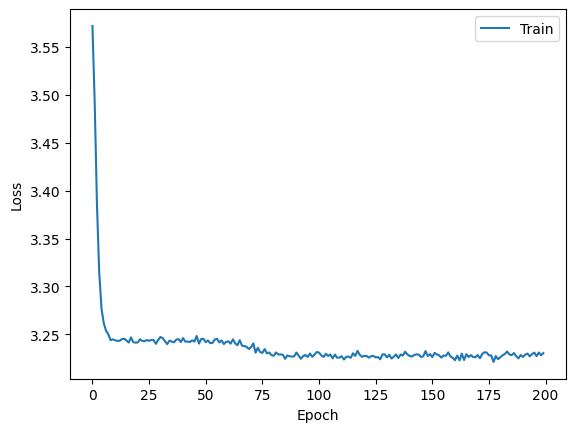

In [58]:
# plot the train and test losses
fig, ax = plt.subplots(dpi=100)
ax.plot(train_losses, label="Train")
# ax.plot(test_losses, color="red", label="Test")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()

In [59]:
t2_prior

TrainableDistributionAdapter(
  distribution_class=<class 'torch.distributions.multivariate_normal.MultivariateNormal'>, loc=tensor([-2.,  2.]), covariance_matrix=tensor([[0.5546, 0.0000],
          [0.0000, 0.9458]])
)

In [60]:
adapted_prior.loc

Parameter containing:
tensor([-1.9945,  2.0280], requires_grad=True)

In [61]:
adapted_prior.covariance_matrix()

tensor([[0.5444, 0.0758],
        [0.0758, 0.8707]], grad_fn=<AddBackward0>)

In [62]:
adapted_posterior = gaussian_posterior(adapted_prior, conditional)

In [63]:
with torch.no_grad():
    adapted_t2_ll = adapted_posterior(t2_train_responses, cond=t2_train_images)
    adapted_t2_ll_test = adapted_posterior(
        t2_test_responses, cond=t2_test_images
    )

In [64]:
adapted_t2_ll_test.mean(), true_t2_ll_test.mean()

(tensor(-1.9324), tensor(-1.9210))

In [65]:
adapted_t2_ll.mean(), true_t2_ll.mean()

(tensor(-1.8946), tensor(-1.8843))